In [5]:
pip install mp-api pymatgen scikit-learn tensorflow

  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl (8.9 MB)
  Using cached tensorflow-2.20.0-cp311-cp311-win_amd64.whl (331.8 MB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl (135 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl (30 kB)
  Using cached gast-0.6.0-py3-none-any.whl (21 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl (26.4 MB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached protobuf-6.33.1-cp310-abi3-win_amd64.whl (436 kB)
  Using cached termcolor-3.2.0-py3-none-any.whl (7.7 kB)
  Using cached grpcio-1.76.0-cp311-cp311-win_amd64.whl (4.7 MB)
  Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
  Using cached keras-3.12.0-py3-none-any.whl (1.5 MB)
  Using cached h5py-3.15.1-cp311-cp311-win_amd64.whl (2.9 MB)
  Using cached ml_dtypes


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
pip install pymatgen

  Using cached pymatgen-2025.10.7-cp311-cp311-win_amd64.whl (3.6 MB)
  Using cached bibtexparser-1.4.3.tar.gz (55 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached matplotlib-3.10.7-cp311-cp311-win_amd64.whl (8.1 MB)
  Using cached monty-2025.3.3-py3-none-any.whl (51 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
  Running setup.py install for bibtexparser: started
  Running setup.py install for bibtexparser: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: bibtexparser is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559

[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install mp-api

  Using cached mp_api-0.45.13-py3-none-any.whl (107 kB)
  Using cached msgpack-1.1.2-cp311-cp311-win_amd64.whl (71 kB)
  Using cached emmet_core-0.86.1-py3-none-any.whl (308 kB)
  Using cached smart_open-7.5.0-py3-none-any.whl (63 kB)
  Using cached boto3-1.41.5-py3-none-any.whl (139 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
  Using cached pydantic_settings-2.12.0-py3-none-any.whl (51 kB)
  Using cached pymatgen_io_validation-0.1.2-py3-none-any.whl (46 kB)
  Using cached pybtex-0.25.1-py2.py3-none-any.whl (127 kB)
  Using cached blake3-1.0.8-cp311-cp311-win_amd64.whl (215 kB)
  Using cached botocore-1.41.5-py3-none-any.whl (14.3 MB)
  Using cached jmespath-1.0.1-py3-none-any.whl (20 kB)
  Using cached s3transfer-0.15.0-py3-none-any.whl (85 kB)
  Using cached wrapt-2.0.1-cp311-cp311-win_amd64.whl (60 kB)
     -------------------------------------- 158.8/158.8 kB 1.2 MB/s eta 0:00:00
  Using cached latexcodec-3.0.1-py3-none-any.whl (18 kB)
  Using cached annotated_type


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import numpy as np
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [30]:
API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"  
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN = 10
TWO_THETA_MAX = 110
N_POINTS = 2048
MAX_PER_CLASS = 10000

In [31]:
def load_perovskite_xrd_from_mp(
    api_key: str,
    max_per_class: int = MAX_PER_CLASS,
    two_theta_min: float = TWO_THETA_MIN,
    two_theta_max: float = TWO_THETA_MAX,
    n_points: int = N_POINTS,
):  
    two_theta_grid = np.linspace(two_theta_min, two_theta_max, n_points)
    X, y = [], []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    xrd_calc = XRDCalculator(wavelength="CuKa")  

    with MPRester(api_key) as mpr:
        robo_docs = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids = [str(doc.material_id) for doc in robo_docs]

        #perov_mpids = perov_mpids[:3000]
        perov_mpids = perov_mpids[:30000]


        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system  

            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()
    
            if cs not in TARGET_SYSTEMS:
                continue
            
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            pattern = xrd_calc.get_pattern(
                structure,
                two_theta_range=(two_theta_min, two_theta_max),
            )
            intensities = np.interp(two_theta_grid, pattern.x, pattern.y)

            X.append(intensities)
            y.append(cs)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    X = np.array(X)  
    y = np.array(y)  

    print("Jumlah sampel per kelas:", class_counts)
    return two_theta_grid, X, y


In [32]:
def build_cnn_1d(input_shape, num_classes: int):
    model = models.Sequential(
        [
            layers.Conv1D(
                filters=32,
                kernel_size=7,
                activation="relu",
                padding="same",
                input_shape=input_shape,
            ),
            layers.MaxPooling1D(pool_size=2),

            layers.Conv1D(
                filters=64,
                kernel_size=5,
                activation="relu",
                padding="same",
            ),
            layers.MaxPooling1D(pool_size=2),

            layers.Conv1D(
                filters=128,
                kernel_size=3,
                activation="relu",
                padding="same",
            ),

            layers.Conv1D(
                filters=256,
                kernel_size=3,
                activation="relu",
                padding="same",
            ),
            
            layers.GlobalAveragePooling1D(),

            layers.Dense(64, activation="relu"),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

Retrieving SummaryDoc documents: 100%|██████████| 7886/7886 [01:23<00:00, 94.25it/s] 


Jumlah sampel per kelas: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}


c:\Users\REVAN\Documents\ML\.venv-1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 57s 381ms/step - accuracy: 0.8037 - loss: 0.4567 - val_accuracy: 0.8210 - val_loss: 0.4200
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 52s 370ms/step - accuracy: 0.8327 - loss: 0.3911 - val_accuracy: 0.8326 - val_loss: 0.3806
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.8401 - loss: 0.3676 - val_accuracy: 0.8549 - val_loss: 0.3616
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 79s 340ms/step - accuracy: 0.8519 - loss: 0.3552 - val_accuracy: 0.8486 - val_loss: 0.3664
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 52s 369ms/step - accuracy: 0.8583 - loss: 0.3440 - val_accuracy: 0.8557 - val_loss: 0.3411
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 54s 382ms/step - accuracy: 0.8697 - loss: 0.3342 - val_accuracy: 0.8557 - val_loss: 0.3331
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 51s 365ms/step - accuracy: 0.8755 - loss: 0.3184 - val_accuracy: 0.8825 - val_loss: 0.3086
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 51s 359ms/step - accuracy: 0.8761 - loss: 0

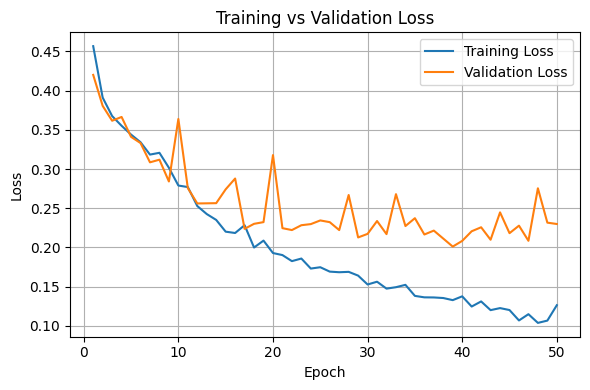

44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step

=== NILAI METRIK (macro-average) ===
Accuracy : 0.9337
Precision: 0.8432
Recall   : 0.8191
F1-score : 0.8304

=== KETERANGAN METRIK ===
Accuracy : proporsi seluruh prediksi yang benar dari semua sampel.
Precision: seberapa 'bersih' prediksi tiap kelas (minim false positive).
Recall   : seberapa banyak sampel tiap kelas yang berhasil tertangkap (minim false negative).
F1-score : rata-rata harmonik precision dan recall, seimbang untuk data yang tidak seimbang.

=== LAPORAN PER KELAS ===
              precision    recall  f1-score   support

       cubic       0.98      0.99      0.99       975
  monoclinic       0.85      0.79      0.82       174
orthorhombic       0.83      0.86      0.85       201
  tetragonal       0.71      0.64      0.67        53

    accuracy                           0.93      1403
   macro avg       0.84      0.82      0.83      1403
weighted avg       0.93      0.93      0.93      1403



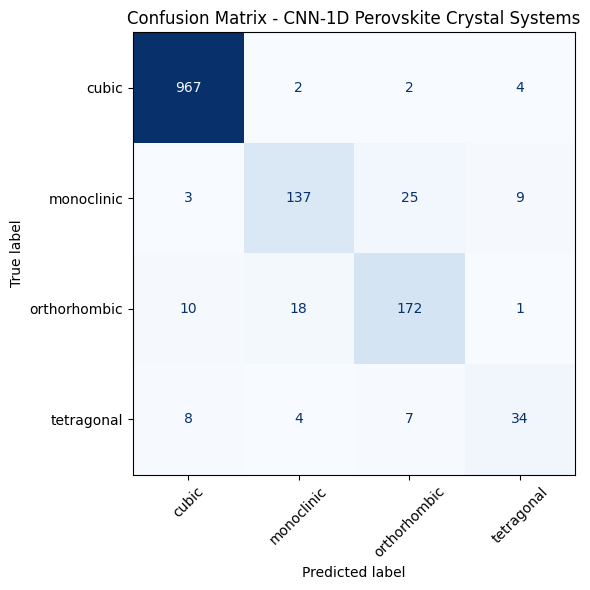

In [33]:
if __name__ == "__main__":
    two_theta, X_raw, y_str = load_perovskite_xrd_from_mp(API_KEY)

    le = LabelEncoder()
    y = le.fit_transform(y_str)  

    X = X_raw[..., np.newaxis]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    model = build_cnn_1d(
        input_shape=X_train.shape[1:],
        num_classes=len(le.classes_),
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=1,
    )

    train_loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(train_loss) + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs_range, train_loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    y_proba = model.predict(X_test)
    y_pred = np.argmax(y_proba, axis=1)


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    print("\n=== NILAI METRIK (macro-average) ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\n=== KETERANGAN METRIK ===")
    print("Accuracy : proporsi seluruh prediksi yang benar dari semua sampel.")
    print("Precision: seberapa 'bersih' prediksi tiap kelas (minim false positive).")
    print("Recall   : seberapa banyak sampel tiap kelas yang berhasil tertangkap (minim false negative).")
    print("F1-score : rata-rata harmonik precision dan recall, seimbang untuk data yang tidak seimbang.")

    print("\n=== LAPORAN PER KELAS ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)

    plt.title("Confusion Matrix - CNN-1D Perovskite Crystal Systems")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
